## Get data from Zenodo

In [1]:
import subprocess
import os

output_dir = './data/'
os.makedirs(output_dir, exist_ok=True)

cmd1 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/PE_O5Like_snr20.h5"] # PE file
cmd2 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5"] # inj file
subprocess.run(cmd1, capture_output=True, text=True)
subprocess.run(cmd2, capture_output=True, text=True)

CompletedProcess(args=['wget', '-c', '-P', './data/', 'https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5'], returncode=0, stdout='', stderr='--2026-06-08 14:49:43--  https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5\nResolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.103.118, 137.138.52.235, ...\nConnecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.\nHTTP request sent, awaiting response... 416 REQUESTED_RANGE_NOT_SATISFIABLE\n\n    The file is already fully retrieved; nothing to do.\n\n')

## Load data

In [3]:
import os, sys
import jax.numpy as jnp 

os.environ['CHIMERA_ENABLE_GPU'] = "False"
sys.path.append(os.getcwd()+'/../')
from CHIMERA import data as data

#file_ev   =  "./data/PE_O5Like_snr20.h5"
file_ev = '/home/mt/projects/gwtc-5/GWTC5_242CBC_FAR0.25_PE2048.h5'
theta_pe_det = data.load_gw_pe_samples(file_ev, 
                                 parameters=['m1det', 'm2det', 'dL'], 
                                 return_struct=True)
#pe_prior = theta_pe_det.dL**2
pe_prior = jnp.load('/home/mt/projects/gwtc-5/GWTC5_242CBC_FAR0.25_PE2048prior.npy')
theta_pe_det = theta_pe_det.update(pe_prior=pe_prior)
nev = len(theta_pe_det.dL)
print(f'Loaded {nev} GW events')

Loaded 242 GW events


## Instantiate population model

In [5]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass.conditioned import plp
from CHIMERA.rate import madau_dickinson
from CHIMERA import population

# define population models with some fiducials
cosmo = flrw(H0 = 70., 
             Om0=0.25, 
             z_max = 5.)
mass = plp(m_low=0.5, m_high=150, lambda_peak=0.039, alpha=3.4, beta=1.1, delta_m=4.8, mu_g=34., sigma_g=3.6)
rate = madau_dickinson(gamma = 2.7,
                       kappa =  3.,
                       zp = 2.)


population = population(cosmo, mass, rate, scale_free=True)

## Instantiate the Selection Function module

In [8]:
from CHIMERA import selection_function

#file_inj = "./data/injections_Ninj_2e7_O5Like_snr20.h5"
file_inj = "/home/mt/projects/gwtc-5/GWTC5_injections_far0.25.h5"
theta_inj_det = data.load_injection_data(file_inj, snr_cut=None, key_mapping={'snr':'snr', 'log_pdraw':'log_pdraw'}, frame='detector')

sel_fcn = selection_function(theta_inj_det, N_inj = 1568035640.0)#N_inj=20*1e6)

## Instantiate the Hyperlike

In [10]:
from CHIMERA import hyperlikelihood

hyperlike = hyperlikelihood(  # data
  theta_gw_det = theta_pe_det,
  # population 
  population=population,
  # integration grid resolution
  z_grids_res = 300,  
  # selection function
  selection_function=sel_fcn,
  # numerical stability
  pe_neff = 2.0,
  inj_neff = None, # default to 5*Nev  
  # KDE settings
  kind_kde = 'binned',
  kernel = 'epan',
  kde_bw = None, # default to scott
  num_bins = 200,
)

2026-07-16 12:49:42,108 - CHIMERA - WARNING - `kde_bw` is None, using Scott rule for bandwidth.
2026-07-16 12:49:42,109 - CHIMERA - INFO - Created hyperlikelihood model. Using 242 GW events.


## 1d on H0

50it [00:16,  3.03it/s]
/tmp/ipykernel_125026/4280466871.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norms_evs = np.trapz(like_evs_H0, x=H0, axis=0)
/tmp/ipykernel_125026/4280466871.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  like_H0 /= np.trapz(like_H0, H0)


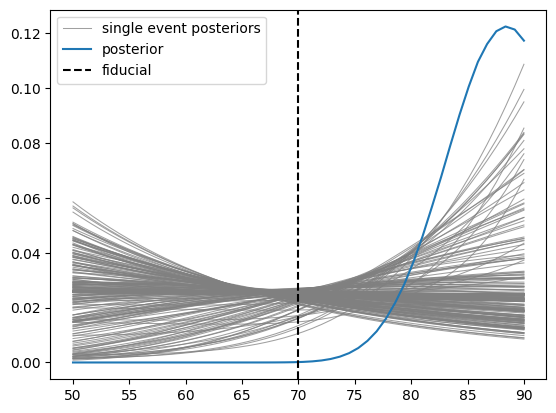

In [11]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt

H0 = np.linspace(50, 90, 50)
log_like_evs_H0 = np.zeros((H0.shape[0], hyperlike.nevents))
loglike_H0 = np.zeros_like(H0)
N_exp_H0 = np.zeros_like(H0)

for i, h0 in tqdm.tqdm(enumerate(H0)):
  log_like_evs, N_exp, neff_inj, log_hyperlike = hyperlike.compute_all(H0=h0)
  log_like_evs_H0[i] = log_like_evs
  N_exp_H0[i] = N_exp
  loglike_H0[i] = log_hyperlike

# exponentiate and normalize
log_like_evs_H0 -= np.nanmax(log_like_evs_H0)
like_evs_H0 = np.exp(log_like_evs_H0) 
norms_evs = np.trapz(like_evs_H0, x=H0, axis=0)

loglike_H0 -= np.nanmax(loglike_H0)
like_H0 = np.exp(loglike_H0)
like_H0 /= np.trapz(like_H0, H0)

for e in range(hyperlike.nevents):
    lab = 'single event posteriors' if e == 0 else None
    plt.plot(H0, like_evs_H0[:,e]/norms_evs[e], c='gray', lw=0.75, alpha=0.75, label = lab )
plt.plot(H0, like_H0, label='posterior')
plt.axvline(70, ls='--', c='k', label= 'fiducial')
plt.legend()
plt.show()